In [2]:
import CS_functions as cs
import numpy as np
from tqdm import tqdm
from matplotlib import pyplot as plt
from scipy import fft as spfft
from scipy.constants import speed_of_light as C
plt.rcParams.update({'font.size':24, 'xtick.minor.visible': True, 'ytick.minor.visible': False,
                     'xtick.direction': 'in', 'ytick.direction': 'in', "xtick.top": True, "ytick.right": True,
                     'lines.linewidth': 2.4, 'lines.markersize': 10.0, 'lines.markeredgewidth': 2.4})

In [19]:
detector_length = 28 #mm
pixel_pitch = 1.5 #mm
theta = 366 # arcminutes
total_points = np.floor(detector_length//pixel_pitch +1).astype(int)

wns = np.fft.rfftfreq(total_points, pixel_pitch*1e-3)
freqs = wns / (2*np.sin(np.deg2rad(theta/60)))
freqs *= C
freqs *= 1e-12
print(total_points)
print(wns)
print(freqs)

19
[  0.          35.0877193   70.1754386  105.26315789 140.35087719
 175.43859649 210.52631579 245.61403509 280.70175439 315.78947368]
[0.         0.04949478 0.09898956 0.14848434 0.19797912 0.2474739
 0.29696868 0.34646346 0.39595824 0.44545302]


In [21]:
travel_length= 49.0 # mm
regularization_coeffient= 1e-2; samples = 8
central_freq= 300e9; FWHM_freq= 75e9
min_points= 25; max_points= 500; N = 5
noise= 0.0

total_points = np.round(np.geomspace(min_points, max_points, N)).astype(int)

targets= list(range(N)); reconstructions= list(range(N)); displacements= list(range(N))
targets_FFT= list(range(N)); reconstructions_FFT= list(range(N)); targets_DCT= list(range(N)); reconstructions_DCT= list(range(N))
test_configs= np.empty((N, samples), dtype= int); scores= np.empty(N)
for n, total_point in tqdm(enumerate(total_points)):
    pixel_pitch = travel_length / (total_point-1)
    displacements[n] = np.arange(-(total_point//2), (total_point+1)//2) *pixel_pitch #in mm
    
    targets[n] = cs.generate_interferogram(total_point, pixel_pitch*1e-3, central_freq, FWHM_freq, 6, noise)
    noiseless = cs.generate_interferogram(total_point, pixel_pitch*1e-3, central_freq, FWHM_freq, 6)
    test_configs[n], scores[n] = cs.MCMC_metropolis(samples, targets[n], noiseless= noiseless, regularization_coeffient= regularization_coeffient, error_type= "L2")
    
    sample = np.full_like(targets[n], np.nan)
    sample[test_configs[n]] = targets[n][test_configs[n]]
    reconstructions[n] = cs.compressed_sensing(sample, regularization_coeffient, norm= "ortho")

    targets_FFT[n] = np.fft.rfft(targets[n])
    targets_FFT[n] = np.abs(targets_FFT[n])
    reconstructions_FFT[n] = np.fft.rfft(reconstructions[n])
    reconstructions_FFT[n] = np.abs(reconstructions_FFT[n])
    targets_DCT[n] = spfft.dct(targets[n], norm= "ortho", type= 1)
    reconstructions_DCT[n] = spfft.dct(reconstructions[n], norm= "ortho", type= 1)


5it [10:39, 127.94s/it]


25 0.008322358606964729
53 0.007641389437361098
112 0.10186949626236609
236 0.0615154700316883
500 0.13406620442967623


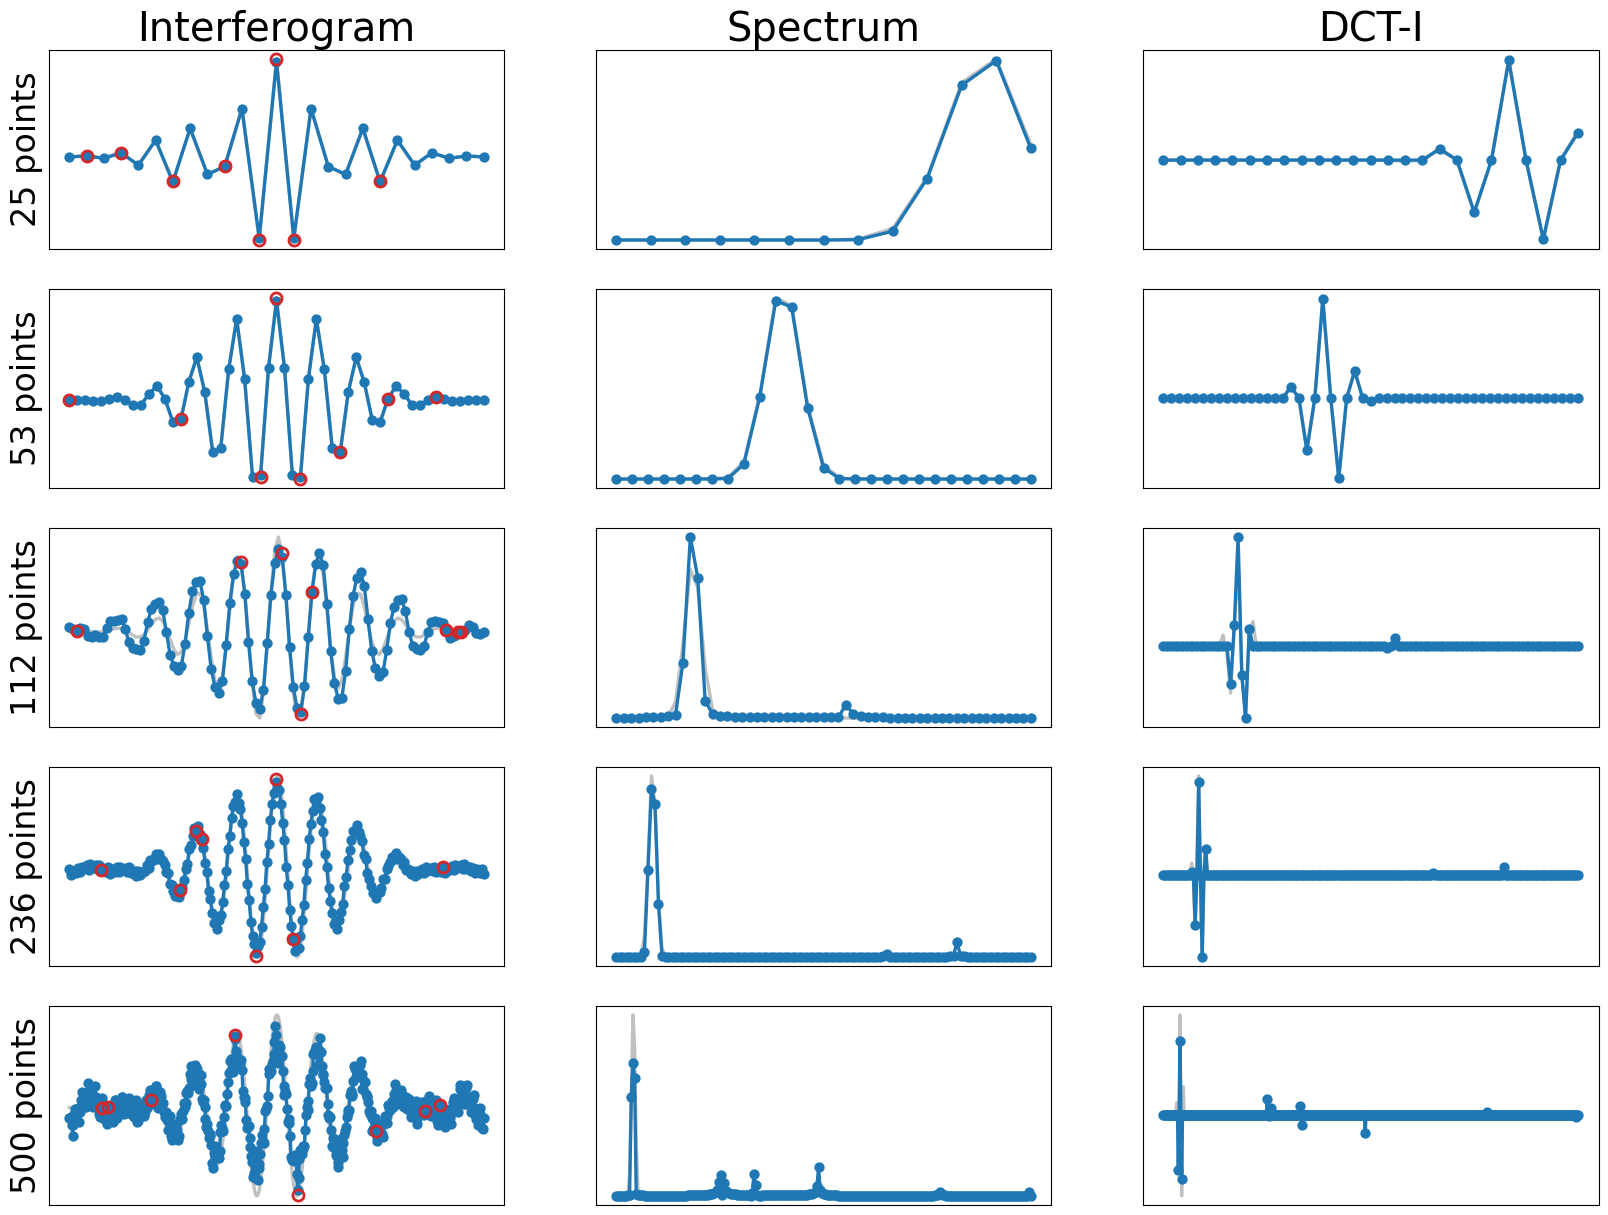

In [28]:
fig, axs = plt.subplots(N, 3, figsize= (20, 3*N))

for n, ax in enumerate(axs):

    ax[0].plot(displacements[n], targets[n], color= "silver")
    ax[0].plot(displacements[n], reconstructions[n], color= "tab:blue", marker= ".")
    ax[0].plot(displacements[n][test_configs[n]], targets[n][test_configs[n]], linestyle= "none", marker= "o", color= "tab:red", markerfacecolor= "none", markeredgewidth= 2, markersize= 8)
    ax[0].set(xticks= [], yticks= [], ylabel= f"{total_points[n]:d} points")

    ax[1].plot(targets_FFT[n], color= "silver")
    ax[1].plot(reconstructions_FFT[n], color= "tab:blue", marker= ".")
    ax[1].set(xticks= [], yticks= [])


    ax[2].plot(targets_DCT[n], color= "silver")
    ax[2].plot(reconstructions_DCT[n], color= "tab:blue", marker= ".")
    ax[2].set(xticks= [], yticks= [])

    print(len(displacements[n]), scores[n])

axs[0,0].set_title("Interferogram")
axs[0,1].set_title("Spectrum")
axs[0,2].set_title("DCT-I")

plt.show()